In [45]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

%matplotlib inline

In [46]:
dt = pd.read_csv('data.csv')
dt = dt.drop('id', axis=1)

dt['diagnosis'] = dt['diagnosis'].map({
    'M': 0,
    'B': 1,
})

train, test = train_test_split(dt, test_size=0.2, random_state=42)

In [47]:
X_train = train.drop('diagnosis', axis=1)
X_test = test.drop('diagnosis', axis=1)

y_train = train['diagnosis']
y_test = test['diagnosis']

X_train = X_train.iloc[:, :-1]
X_test = X_test.iloc[:, :-1]

In [48]:
X_train = (X_train - X_train.mean()) / X_train.std()
X_test = (X_test - X_test.mean()) / X_test.std()

In [49]:
class CancerNet(nn.Module):
    def __init__(self):
        super(CancerNet, self).__init__()
        self.l1 = nn.Linear(30, 128)
        self.l2 = nn.Linear(128, 128)
        self.l3 = nn.Linear(128, 64)
        self.l4 = nn.Linear(64, 2)
        

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        x = F.relu(self.l3(x))
        return self.l4(x)

model = CancerNet()

optim = torch.optim.Adam(model.parameters())
lossfn = nn.CrossEntropyLoss()

losses, accs = [], []

X = torch.tensor(X_train.values).float()
Y = torch.tensor(y_train.values).long()

for _ in range(400):
    optim.zero_grad()
    out = model(X)
    cat = torch.argmax(out, dim=1)
    acc = (cat == Y).float().mean()
    loss = lossfn(out, Y)
    
    loss.backward(); optim.step()
    loss, acc = loss.item(), acc.item()

    losses.append(loss); accs.append(acc)


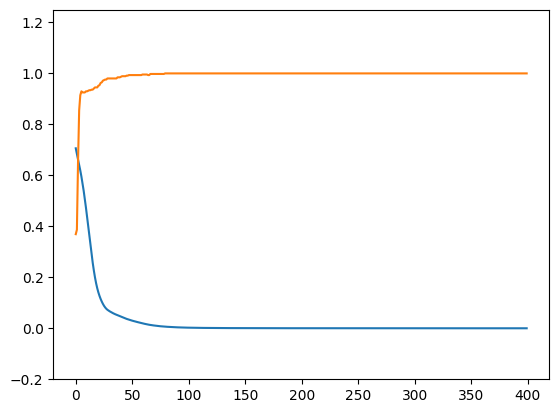

In [53]:
plt.ylim(-0.2, 1.25)
plt.plot(losses)
plt.plot(accs)

In [51]:
X_test_tensor = torch.tensor(X_test.values).float()
y_test_tensor = torch.tensor(y_test.values).long()

preds = torch.argmax(model(X_test_tensor), dim=1)

acc = (preds == y_test_tensor).float().mean()

print(f"Accuracy of model on test data: {acc.item():.4f}")

Accuracy of model on test data: 0.9737
